Imports

In [3]:
import os, pickle, random
from pathlib import Path
 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
 
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report
)
 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


Paths

In [4]:
DATA_ROOT     = Path("/kaggle/input/datasets/sahilakolte/vr-project-1/processed")
TRAIN_IMG_DIR = DATA_ROOT / "train"      / "images"
VAL_IMG_DIR   = DATA_ROOT / "validation" / "images"
CKPT_DIR      = Path("/kaggle/working/mobilenet_scratch")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

Load pkl files

In [5]:
with open(DATA_ROOT / "train_labels.pkl", "rb") as f:
    train_labels = pickle.load(f)   # dict: {"000001.jpg": np.array([0,1,0,0,1])}
with open(DATA_ROOT / "val_labels.pkl", "rb") as f:
    val_labels = pickle.load(f)
with open(DATA_ROOT / "class_weights.pkl", "rb") as f:
    class_weights_data = pickle.load(f)
with open(DATA_ROOT / "top5.pkl", "rb") as f:
    top5_data = pickle.load(f)      # list: [1, 8, 7, 2, 9]  (original category IDs)
with open(DATA_ROOT / "label_map.pkl", "rb") as f:
    label_map = pickle.load(f)      # dict: {1:0, 8:1, 7:2, 2:3, 9:4}
 
print("train_labels — type:", type(train_labels), " len:", len(train_labels))
print("top5_data   :", top5_data)
print("label_map   :", label_map)

train_labels — type: <class 'dict'>  len: 144174
top5_data   : [1, 8, 7, 2, 9]
label_map   : {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}


Class names & records

In [6]:
ALL_CATEGORIES = {
    1:"short_sleeve_top",    2:"long_sleeve_top",
    3:"short_sleeve_outwear",4:"long_sleeve_outwear",
    5:"vest",                6:"sling",
    7:"shorts",              8:"trousers",
    9:"skirt",               10:"short_sleeve_dress",
    11:"long_sleeve_dress",  12:"vest_dress",
    13:"sling_dress"
}
 
CLASS_NAMES = [ALL_CATEGORIES[cat_id] for cat_id in top5_data]
NUM_CLASSES  = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")
 
def build_records(labels_dict, img_dir):
    """
    labels_dict : {"000001.jpg": np.array([0,1,0,0,1]), ...}
    img_dir     : Path to images folder
    Returns     : list of {"img_path": str, "multilabel": list}
    """
    records = []
    for filename, label_arr in labels_dict.items():
        img_path = img_dir / filename
        if not img_path.exists():
            continue
        records.append({
            "img_path":   str(img_path),
            "multilabel": list(np.array(label_arr, dtype=np.float32)),
        })
    return records

train_records = build_records(train_labels, TRAIN_IMG_DIR)
val_records   = build_records(val_labels,   VAL_IMG_DIR)

# ── Stratified sampling — keep class balance ──────────────────
def stratified_sample(records, fraction=1, num_classes=5, seed=42):
    """
    Sample a fraction of records while maintaining per-class distribution.
    Each class gets at least min_per_class samples.
    """
    random.seed(seed)
    # Bucket records by which classes they contain
    class_buckets = {i: [] for i in range(num_classes)}
    for rec in records:
        for i, v in enumerate(rec["multilabel"]):
            if v == 1.0:
                class_buckets[i].append(rec)

    print("Class distribution before sampling:")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  [{i}] {name:<28s}: {len(class_buckets[i])} images")

    # Sample fraction from each bucket, deduplicate by img_path
    sampled = {}
    for i in range(num_classes):
        bucket  = class_buckets[i]
        n       = max(500, int(len(bucket) * fraction))  # at least 500 per class
        chosen  = random.sample(bucket, min(n, len(bucket)))
        for rec in chosen:
            sampled[rec["img_path"]] = rec   # deduplicate

    sampled_records = list(sampled.values())
    random.shuffle(sampled_records)

    print(f"\nAfter sampling: {len(sampled_records)} / {len(records)} images ({len(sampled_records)/len(records)*100:.1f}%)")
    print("Class distribution after sampling:")
    for i, name in enumerate(CLASS_NAMES):
        count = sum(1 for r in sampled_records if r["multilabel"][i] == 1.0)
        print(f"  [{i}] {name:<28s}: {count} images")

    return sampled_records

train_records = train_records

# Normal val/test split (no sampling needed — val is already small)
random.shuffle(val_records)
mid          = len(val_records) // 2
test_records = val_records[mid:]
val_records  = val_records[:mid]

print(f"\nFinal splits — Train:{len(train_records)}  Val:{len(val_records)}  Test:{len(test_records)}")
assert len(train_records) > 0, "No training images found"


Classes (5): ['short_sleeve_top', 'trousers', 'shorts', 'long_sleeve_top', 'skirt']

Final splits — Train:144174  Val:11870  Test:11871


In [7]:
if isinstance(class_weights_data, dict):
    sorted_w   = [v for _, v in sorted(class_weights_data.items())]
    pos_weights = np.array(sorted_w[:NUM_CLASSES], dtype=np.float32)
elif isinstance(class_weights_data, (list, np.ndarray)):
    pos_weights = np.array(class_weights_data, dtype=np.float32)
else:
    pos_weights = np.ones(NUM_CLASSES, dtype=np.float32)
 
if len(pos_weights) != NUM_CLASSES:
    print("Recomputing class weights from training data...")
    all_labels   = np.array([r["multilabel"] for r in train_records])
    class_counts = all_labels.sum(axis=0)
    N            = len(train_records)
    pos_weights  = ((N - class_counts) / (class_counts + 1e-6)).astype(np.float32)
 
pos_weights_t = torch.tensor(pos_weights).to(device)
print(f"pos_weights: {pos_weights}")

pos_weights: [0.40850595 0.52456474 0.79364747 0.80654526 0.9415445 ]


Dataset

In [8]:
class ApparelDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records   = records
        self.transform = transform
 
    def __len__(self):
        return len(self.records)
 
    def __getitem__(self, idx):
        rec = self.records[idx]
        try:
            img = Image.open(rec["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), 0)
        label = torch.tensor(rec["multilabel"], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, label
 
IMG_SIZE = 224
 
train_transform = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
 
train_ds = ApparelDataset(train_records, train_transform)
val_ds   = ApparelDataset(val_records,   val_transform)
test_ds  = ApparelDataset(test_records,  val_transform)
 
BATCH_SIZE   = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"Batches — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}")
 


Batches — train:4506  val:371  test:371


Model

In [9]:
model = models.mobilenet_v3_large(weights=None)   # random init
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
model = model.to(device)
print(f"MobileNetV3-Large (scratch) — params: {sum(p.numel() for p in model.parameters()):,}")

MobileNetV3-Large (scratch) — params: 4,208,437


Loss / Optimizer / Scheduler

In [10]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_t)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

Train & eval functions

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)
 
@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="Eval", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels).astype(int)
    preds  = (probs >= threshold).astype(int)
    return (total_loss / len(loader.dataset),
            f1_score(labels, preds, average="micro", zero_division=0),
            f1_score(labels, preds, average="macro", zero_division=0),
            probs, labels)

Training loop

In [12]:
EPOCHS  = 20
best_f1 = 0.0
history = {"train_loss": [], "val_loss": [], "micro_f1": [], "macro_f1": []}
 
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, micro_f1, macro_f1, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()
 
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["micro_f1"].append(micro_f1)
    history["macro_f1"].append(macro_f1)
 
    print(f"Epoch {epoch:03d}/{EPOCHS} | Train: {tr_loss:.4f} | "
          f"Val: {va_loss:.4f} | Micro-F1: {micro_f1:.4f} | Macro-F1: {macro_f1:.4f}")
 
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "macro_f1": macro_f1, "class_names": CLASS_NAMES},
                   CKPT_DIR / "best_model.pt")
        print(f"  ✓ Saved (Macro-F1={macro_f1:.4f})")
 
print(f"\nBest Val Macro-F1: {best_f1:.4f}")


Epoch 001/20 | Train: 0.4354 | Val: 0.4271 | Micro-F1: 0.2648 | Macro-F1: 0.1858
  ✓ Saved (Macro-F1=0.1858)


Epoch 002/20 | Train: 0.4051 | Val: 0.4011 | Micro-F1: 0.3047 | Macro-F1: 0.2724
  ✓ Saved (Macro-F1=0.2724)


Epoch 003/20 | Train: 0.3897 | Val: 0.4021 | Micro-F1: 0.2950 | Macro-F1: 0.2667


Epoch 004/20 | Train: 0.3824 | Val: 0.3920 | Micro-F1: 0.3773 | Macro-F1: 0.3289
  ✓ Saved (Macro-F1=0.3289)


Epoch 005/20 | Train: 0.3762 | Val: 0.3935 | Micro-F1: 0.4503 | Macro-F1: 0.4161
  ✓ Saved (Macro-F1=0.4161)


...

Epoch 016/20 | Train: 0.3254 | Val: 0.3206 | Micro-F1: 0.5914 | Macro-F1: 0.5633


Epoch 017/20 | Train: 0.3224 | Val: 0.3170 | Micro-F1: 0.6034 | Macro-F1: 0.5886
  ✓ Saved (Macro-F1=0.5886)


Epoch 018/20 | Train: 0.3192 | Val: 0.3147 | Micro-F1: 0.6339 | Macro-F1: 0.6081
  ✓ Saved (Macro-F1=0.6081)


Epoch 019/20 | Train: 0.3157 | Val: 0.3046 | Micro-F1: 0.6540 | Macro-F1: 0.6312
  ✓ Saved (Macro-F1=0.6312)


Epoch 020/20 | Train: 0.3126 | Val: 0.3023 | Micro-F1: 0.6348 | Macro-F1: 0.6211

Best Val Macro-F1: 0.6312


Training curves

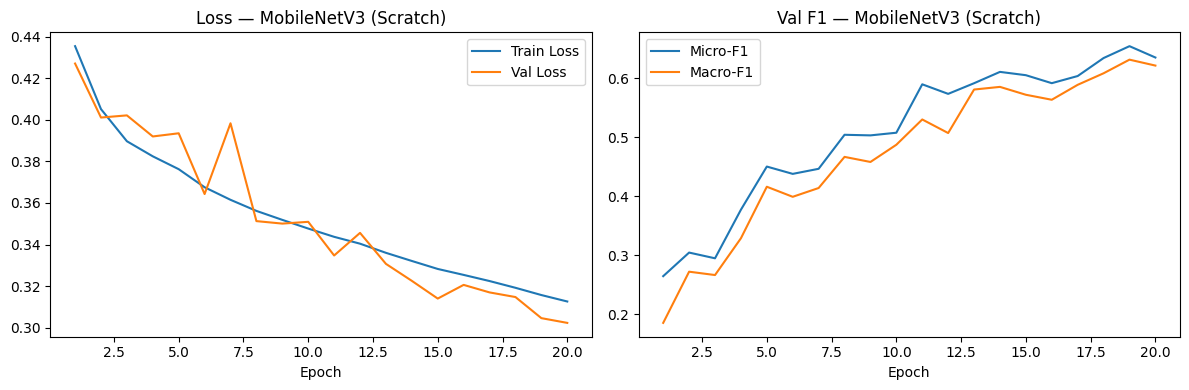

In [13]:
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ep, history["train_loss"], label="Train Loss")
axes[0].plot(ep, history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss — MobileNetV3 (Scratch)")
axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(ep, history["micro_f1"], label="Micro-F1")
axes[1].plot(ep, history["macro_f1"], label="Macro-F1")
axes[1].set_title("Val F1 — MobileNetV3 (Scratch)")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(CKPT_DIR / "training_curves.png", dpi=100)
plt.show()

Test set evaluation

In [17]:
ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model — epoch {ckpt['epoch']}  Macro-F1={ckpt['macro_f1']:.4f}")
 
te_loss, te_micro, te_macro, te_probs, te_labels = evaluate(model, test_loader, criterion, device)
te_preds = (te_probs >= 0.5).astype(int)

print(f"\n{'='*55}")
print("TEST RESULTS — MobileNetV3 (From Scratch)")
print(f"{'='*55}")
print(f"Loss     : {te_loss:.4f}") 
print(f"Micro-F1 : {te_micro:.4f}")
print(f"Macro-F1 : {te_macro:.4f}")

print(f"\nPer-class report:")
print(classification_report(te_labels, te_preds, target_names=CLASS_NAMES, zero_division=0))

Loaded best model — epoch 19  Macro-F1=0.6312



TEST RESULTS — MobileNetV3 (From Scratch)
Loss     : 0.3068
Micro-F1 : 0.6521
Macro-F1 : 0.6272

Per-class report:
                  precision    recall  f1-score   support

short_sleeve_top       0.91      0.48      0.63      6160
        trousers       0.87      0.76      0.81      4716
          shorts       0.79      0.50      0.61      2067
 long_sleeve_top       0.65      0.37      0.47      2962
           skirt       0.76      0.51      0.61      3247

       micro avg       0.82      0.54      0.65     19152
       macro avg       0.80      0.52      0.63     19152
    weighted avg       0.82      0.54      0.64     19152
     samples avg       0.63      0.53      0.55     19152



ROC curves

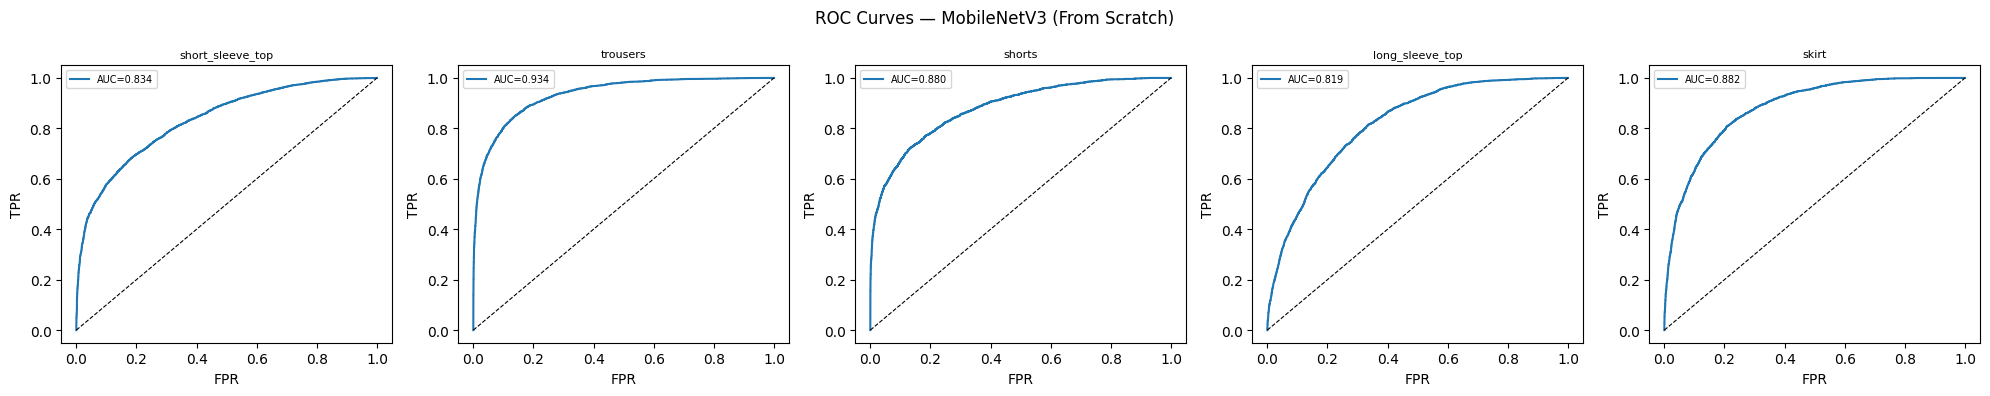

In [15]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
for i, name in enumerate(CLASS_NAMES):
    try:
        fpr, tpr, _ = roc_curve(te_labels[:, i], te_probs[:, i])
        auc = roc_auc_score(te_labels[:, i], te_probs[:, i])
        axes[i].plot(fpr, tpr, label=f"AUC={auc:.3f}")
    except Exception:
        axes[i].text(0.5, 0.5, "N/A", ha="center")
    axes[i].plot([0,1],[0,1],"k--", lw=0.8)
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlabel("FPR"); axes[i].set_ylabel("TPR")
    axes[i].legend(fontsize=7)
plt.suptitle("ROC Curves — MobileNetV3 (From Scratch)")
plt.tight_layout()
plt.savefig(CKPT_DIR / "roc_curves.png", dpi=100)
plt.show()

Save results

In [16]:
results = {
    "model": "MobileNetV3-Large", "training": "from_scratch",
    "test_loss": te_loss, "micro_f1": te_micro, "macro_f1": te_macro,
    "per_class_precision": precision_score(te_labels, te_preds, average=None, zero_division=0).tolist(),
    "per_class_recall":    recall_score(te_labels,    te_preds, average=None, zero_division=0).tolist(),
    "per_class_f1":        f1_score(te_labels,        te_preds, average=None, zero_division=0).tolist(),
    "class_names": CLASS_NAMES,
}
with open(CKPT_DIR / "results.pkl", "wb") as f:
    pickle.dump(results, f)
print(f"All outputs saved to: {CKPT_DIR}")

All outputs saved to: /kaggle/working/mobilenet_scratch
